### 1] Importing all the libraries necessary for this project

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

### 2] Load Data from CSV

In [2]:
df = pd.read_csv("data/data.csv", encoding='windows-1250')

In [3]:
# Head of the dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### 3] Data cleaning

In [6]:
# Negative price - check if double negative values
df[(df['UnitPrice']<0) & (df['Quantity']<0)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [7]:
# No double negatives - check if negative price is incorrect value
df[df['UnitPrice']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,NaN,United Kingdom


Description "Adjust bad debt" -> not related to RFM

In [8]:
# Check null values
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
# Create dataset for RFM
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0) & (df['CustomerID'].notna())].copy()

In [10]:
# Fix types
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['Country'] = df_clean['Country'].astype('category')
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,397884.000000,397884,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,179.331775,NaN,22.097877,1713.141560


### 4] Add revenue column

No double negative values. Add revenue column using simple equation.

In [11]:
df_quantity = df_clean['Quantity']
df_unitprice = df_clean['UnitPrice']
df_full = df_clean.copy()
df_full['Revenue'] = df_quantity*df_unitprice
df_full['Revenue']

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: Revenue, Length: 397884, dtype: float64

### 5] Data analysis

#### A) Create customer table

Start with basic aggregation. Values per customer

In [12]:
customer_table = df_full.groupby('CustomerID').agg(
    TotalRevenue=('Revenue', 'sum'),
    TotalOrders=('InvoiceNo', 'nunique'),
    TotalTransactions=('InvoiceNo', 'count'),
    TotalQuantity=('Quantity', 'sum'),
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max')
).reset_index()
customer_table.head()

,CustomerID,TotalRevenue,TotalOrders,TotalTransactions,TotalQuantity,FirstPurchase,LastPurchase
0,12346,77183.60,1,1,74215,2011-01-18 10:01:00,2011-01-18 10:01:00
1,12347,4310.00,7,182,2458,2010-12-07 14:57:00,2011-12-07 15:52:00
2,12348,1797.24,4,31,2341,2010-12-16 19:09:00,2011-09-25 13:13:00
3,12349,1757.55,1,73,631,2011-11-21 09:51:00,2011-11-21 09:51:00
4,12350,334.40,1,17,197,2011-02-02 16:01:00,2011-02-02 16:01:00


In [13]:
customer_table['AvgOrderValue'] = (
    customer_table['TotalRevenue'] / customer_table['TotalOrders']
)
customer_table.head()

,CustomerID,TotalRevenue,TotalOrders,TotalTransactions,TotalQuantity,FirstPurchase,LastPurchase,AvgOrderValue
0,12346,77183.60,1,1,74215,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000
1,12347,4310.00,7,182,2458,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286
2,12348,1797.24,4,31,2341,2010-12-16 19:09:00,2011-09-25 13:13:00,449.310000
3,12349,1757.55,1,73,631,2011-11-21 09:51:00,2011-11-21 09:51:00,1757.550000
4,12350,334.40,1,17,197,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000


In [14]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

In [15]:
customer_table['Recency'] = (
    snapshot_date - customer_table['LastPurchase']
).dt.days
customer_table.head()

,CustomerID,TotalRevenue,TotalOrders,TotalTransactions,TotalQuantity,FirstPurchase,LastPurchase,AvgOrderValue,Recency
0,12346,77183.60,1,1,74215,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000,326
1,12347,4310.00,7,182,2458,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286,2
2,12348,1797.24,4,31,2341,2010-12-16 19:09:00,2011-09-25 13:13:00,449.310000,75
3,12349,1757.55,1,73,631,2011-11-21 09:51:00,2011-11-21 09:51:00,1757.550000,19
4,12350,334.40,1,17,197,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000,310


#### B) Pareto analysis

In [24]:
# sort customers by revenue
customer_table = customer_table.sort_values('TotalRevenue', ascending=False)
customer_table

,CustomerID,TotalRevenue,TotalOrders,TotalTransactions,TotalQuantity,FirstPurchase,LastPurchase,AvgOrderValue,Recency
1689,14646,280206.02,73,2076,196915,2010-12-20 10:09:00,2011-12-08 12:12:00,3838.438630,2
4201,18102,259657.30,60,431,64124,2010-12-07 16:42:00,2011-12-09 11:50:00,4327.621667,1
3728,17450,194550.79,46,337,69993,2010-12-07 09:23:00,2011-12-01 13:29:00,4229.365000,8
3008,16446,168472.50,2,3,80997,2011-05-18 09:52:00,2011-12-09 09:15:00,84236.250000,1
1879,14911,143825.06,201,5675,80265,2010-12-01 14:05:00,2011-12-08 15:54:00,715.547562,1
...,...,...,...,...,...,...,...,...,...
3323,16878,13.30,1,3,12,2011-09-16 17:39:00,2011-09-16 17:39:00,13.300000,84
4098,17956,12.75,1,1,1,2011-04-04 13:47:00,2011-04-04 13:47:00,12.750000,249
3014,16454,6.90,2,2,3,2011-10-06 16:57:00,2011-10-26 11:40:00,3.450000,45
1793,14792,6.20,1,2,2,2011-10-07 09:19:00,2011-10-07 09:19:00,6.200000,64


In [27]:
#add revenue share per customer
customer_table['RevenueShare'] = (
    customer_table['TotalRevenue'] / customer_table['TotalRevenue'].sum()
)

customer_table['CumulativeShare'] = customer_table['RevenueShare'].cumsum()
customer_table

,CustomerID,TotalRevenue,TotalOrders,TotalTransactions,TotalQuantity,FirstPurchase,LastPurchase,AvgOrderValue,Recency,RevenueShare,CumulativeShare
1689,14646,280206.02,73,2076,196915,2010-12-20 10:09:00,2011-12-08 12:12:00,3838.438630,2,3.144352e-02,0.031444
4201,18102,259657.30,60,431,64124,2010-12-07 16:42:00,2011-12-09 11:50:00,4327.621667,1,2.913763e-02,0.060581
3728,17450,194550.79,46,337,69993,2010-12-07 09:23:00,2011-12-01 13:29:00,4229.365000,8,2.183166e-02,0.082413
3008,16446,168472.50,2,3,80997,2011-05-18 09:52:00,2011-12-09 09:15:00,84236.250000,1,1.890526e-02,0.101318
1879,14911,143825.06,201,5675,80265,2010-12-01 14:05:00,2011-12-08 15:54:00,715.547562,1,1.613943e-02,0.117457
...,...,...,...,...,...,...,...,...,...,...,...
3323,16878,13.30,1,3,12,2011-09-16 17:39:00,2011-09-16 17:39:00,13.300000,84,1.492469e-06,0.999997
4098,17956,12.75,1,1,1,2011-04-04 13:47:00,2011-04-04 13:47:00,12.750000,249,1.430750e-06,0.999998
3014,16454,6.90,2,2,3,2011-10-06 16:57:00,2011-10-26 11:40:00,3.450000,45,7.742884e-07,0.999999
1793,14792,6.20,1,2,2,2011-10-07 09:19:00,2011-10-07 09:19:00,6.200000,64,6.957374e-07,1.000000


In [31]:
#how many customers makes 80% of share
pareto_80 = customer_table[customer_table['CumulativeShare'] <= 0.8]
len(pareto_80)

1132

In [34]:
#share of all customers
pareto_80.shape[0] / customer_table.shape[0]

0.26094974642692487

The Pareto analysis shows that approximately 26% of customers generate 80% of total revenue.
This indicates a moderate level of revenue concentration within a relatively small group of customers.
While the business is not extremely dependent on a very small elite group, the top quarter of customers plays a critical role in overall performance.

In [37]:
# Revenue distribution
customer_table['TotalRevenue'].describe()

count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
25%         307.415000
50%         674.485000
75%        1661.740000
max      280206.020000
Name: TotalRevenue, dtype: float64

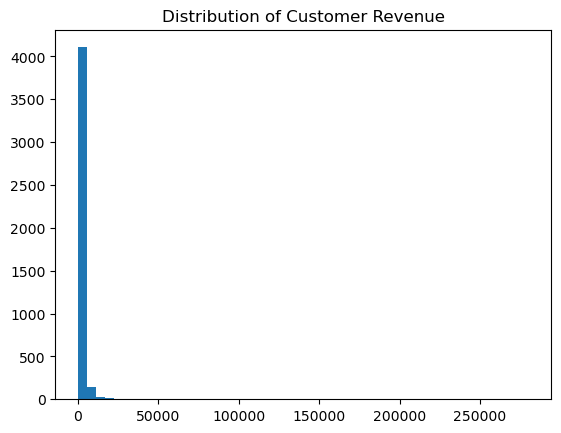

In [42]:
#bar diagram

plt.hist(customer_table['TotalRevenue'], bins=50)
plt.title("Distribution of Customer Revenue")
plt.show()

The distribution of customer revenue is highly right-skewed.
The majority of customers generate relatively low revenue and place a small number of orders, while a small subset of customers accounts for a disproportionately large share of total revenue.
This long-tail structure is typical for retail and e-commerce businesses.

#### C) RFM Analysis

In [49]:
customer_table['R_Score'] = pd.qcut(customer_table['Recency'], 4, labels=[4,3,2,1])
customer_table['F_Score'] = pd.qcut(customer_table['TotalOrders'].rank(method='first'), 4, labels=[1,2,3,4])
customer_table['M_Score'] = pd.qcut(customer_table['TotalRevenue'], 4, labels=[1,2,3,4])

customer_table['RFM_Score'] = (
    customer_table['R_Score'].astype(str) +
    customer_table['F_Score'].astype(str) +
    customer_table['M_Score'].astype(str)
)

The customer-level table was created by aggregating transactional data to the CustomerID level.
For each customer, total revenue, number of unique orders, total number of transactions, total quantity purchased, as well as first and last purchase dates were calculated.
This transformation allows the analysis to shift from individual transactions to customer behavior.

The analysis reveals a clear segmentation potential within the customer base.
A distinct high-value group can be identified, suggesting opportunities for targeted retention and loyalty strategies.
At the same time, a large share of low-frequency customers represents potential for growth through re-engagement initiatives.

In [50]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Zakładamy, że "lost" = brak zakupu w ostatnim roku
lost_customers = customer_table[customer_table['LastPurchase'] < (snapshot_date - pd.Timedelta(days=365))]

len(lost_customers)

77

In [55]:
# segment wg M_Score (Monetary)
revenue_by_segment = customer_table.groupby('M_Score', observed=True)['TotalRevenue'].sum().sort_values(ascending=False)
revenue_by_segment

M_Score
4    7051545.651
3    1161895.311
2     503529.452
1     194437.490
Name: TotalRevenue, dtype: float64

In [58]:
revenue_by_country = df_full.groupby('Country', observed=False)['Revenue'].sum().sort_values(ascending=False)
revenue_by_country

Country
United Kingdom          7308391.554
Netherlands              285446.340
EIRE                     265545.900
Germany                  228867.140
France                   209024.050
Australia                138521.310
Spain                     61577.110
Switzerland               56443.950
Belgium                   41196.340
Sweden                    38378.330
Japan                     37416.370
Norway                    36165.440
Portugal                  33439.890
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20450.440
Denmark                   18955.340
Italy                     17483.240
Cyprus                    13590.380
Austria                   10198.680
Poland                     7334.650
Israel                     7221.690
Greece                     4760.520
Iceland                    4310.000
Canada                     3666.380
USA                        3580.390
Malta                      2725.590
Unspecified         

In [59]:
uk_share = revenue_by_country['United Kingdom'] / revenue_by_country.sum()
uk_share

np.float64(0.8201163758556641)

<Axes: title={'center': 'Monthly Revenue'}, xlabel='YearMonth'>

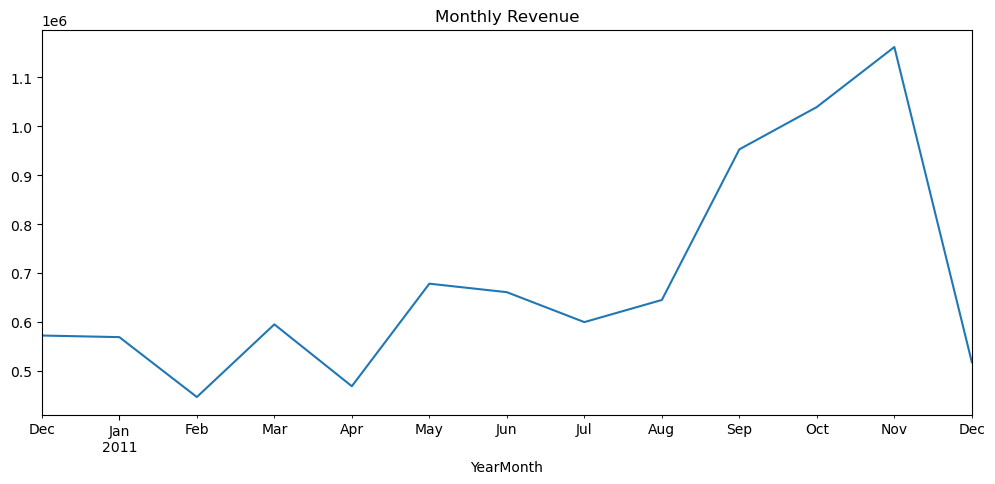

In [62]:
df_full['YearMonth'] = df_full['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_full.groupby('YearMonth')['Revenue'].sum()
monthly_revenue.plot(kind='line', figsize=(12,5), title='Monthly Revenue')

In [16]:
#top_products = df_full.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
#top_products

In [19]:
#df_clean.loc[:, 'InvoiceDate'] = pd.to_datetime(df_full['InvoiceDate'])
#monthly_revenue = df_full.resample('ME', on='InvoiceDate')['Revenue'].sum()
#monthly_revenue.plot(kind='line')